# Exploratory Data Analysis: Bank Marketing Campaign Dataset (UCI / BFSI Domain)

**Dataset:** Bank Marketing (Portuguese retail bank direct marketing campaigns for term deposit subscription)
**Source:** UCI Machine Learning Repository — S. Moro, P. Cortez, P. Rita (2014), "A Data-Driven Approach to Predict the Success of Bank Telemarketing"
**Records:** 41,188 client contacts | **Features:** 20 predictors + 1 target (`y`)
**Business context:** A Portuguese bank ran repeated phone-based marketing campaigns to sell term deposits.
This EDA investigates which client, campaign and macro-economic factors are associated with a client
subscribing to a term deposit — directly relevant to BFSI customer analytics / campaign targeting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = "figures"

df = pd.read_csv("data/bank.csv", sep=";")
df.columns = [c.replace(".", "_") for c in df.columns]
print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Data Overview & Quality Checks

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values (NaN) per column:\n", df.isna().sum().sum(), "total")
print("\n'unknown' category counts (treated as missing for categoricals):")
cat_cols = df.select_dtypes(include="object").columns.tolist()
unk = {c: (df[c] == "unknown").sum() for c in cat_cols if (df[c] == "unknown").sum() > 0}
print(unk)

Duplicate rows: 12

Missing values (NaN) per column:
 0 total

'unknown' category counts (treated as missing for categoricals):
{'job': np.int64(330), 'marital': np.int64(80), 'education': np.int64(1731), 'default': np.int64(8597), 'housing': np.int64(990), 'loan': np.int64(990)}


In [4]:
# Drop exact duplicate rows; keep 'unknown' as an explicit category (informative missingness)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

# pdays = 999 is a sentinel meaning "client was not previously contacted"
df["was_previously_contacted"] = np.where(df["pdays"] == 999, "No", "Yes")
print(df["was_previously_contacted"].value_counts())

Shape after dropping duplicates: (41176, 21)
was_previously_contacted
No     39661
Yes     1515
Name: count, dtype: int64


## 2. Descriptive Statistics

### 2.1 Numeric features — central tendency & dispersion

In [5]:
num_cols = ["age", "duration", "campaign", "pdays", "previous",
            "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,41176.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00,0.78,0.79
duration,41176.0,258.32,259.31,0.00,102.00,180.00,319.00,4918.00,3.26,20.24
campaign,41176.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00,4.76,36.97
pdays,41176.0,962.46,186.94,0.00,999.00,999.00,999.00,999.00,-4.92,22.22
previous,41176.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00,3.83,20.10
emp_var_rate,41176.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40,-0.72,-1.06
cons_price_idx,41176.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77,-0.23,-0.83
cons_conf_idx,41176.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90,0.30,-0.36
euribor3m,41176.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04,-0.71,-1.41
nr_employed,41176.0,5167.03,72.25,4963.60,5099.10,5191.00,5228.10,5228.10,-1.04,-0.00


In [6]:
desc.round(2).to_csv("summary_numeric_stats.csv")

### 2.2 Categorical features — frequency distribution

In [7]:
for c in ["job", "marital", "education", "contact", "poutcome", "y"]:
    print(f"\n--- {c} ---")
    print(df[c].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


--- job ---
job
admin.            25.3%
blue-collar      22.47%
technician       16.37%
services          9.63%
management         7.1%
retired           4.17%
entrepreneur      3.54%
self-employed     3.45%
housemaid         2.57%
unemployed        2.46%
student           2.13%
unknown            0.8%
Name: proportion, dtype: str

--- marital ---
marital
married     60.52%
single      28.08%
divorced     11.2%
unknown      0.19%
Name: proportion, dtype: str

--- education ---
education
university.degree      29.54%
high.school             23.1%
basic.9y               14.68%
professional.course    12.73%
basic.4y               10.14%
basic.6y                5.56%
unknown                  4.2%
illiterate              0.04%
Name: proportion, dtype: str

--- contact ---
contact
cellular     63.47%
telephone    36.53%
Name: proportion, dtype: str

--- poutcome ---
poutcome
nonexistent    86.34%
failure        10.33%
success         3.33%
Name: proportion, dtype: str

--- y ---
y
no     88

### 2.3 Target class balance

y
no     36537
yes     4639
Name: count, dtype: int64 

y
no     88.73
yes    11.27
Name: proportion, dtype: float64


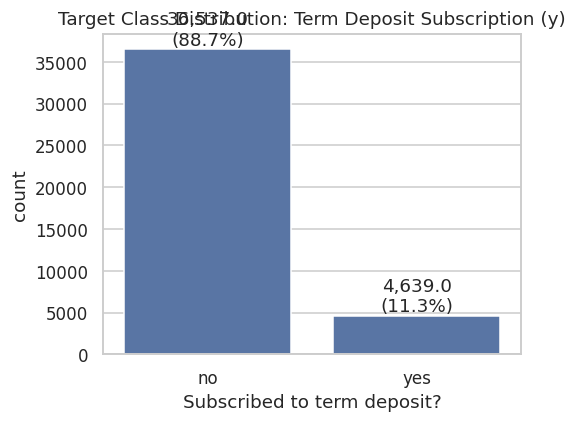

In [8]:
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100
print(target_counts, "\n")
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="y", ax=ax, order=["no", "yes"])
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}\n({100*p.get_height()/len(df):.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set_title("Target Class Distribution: Term Deposit Subscription (y)")
ax.set_xlabel("Subscribed to term deposit?")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_target_balance.png")
plt.show()

**Observation:** The dataset is heavily **imbalanced** — only ~11% of clients subscribed. Any downstream
predictive model must account for this (stratified sampling, class weights, or resampling).

## 3. Univariate Analysis

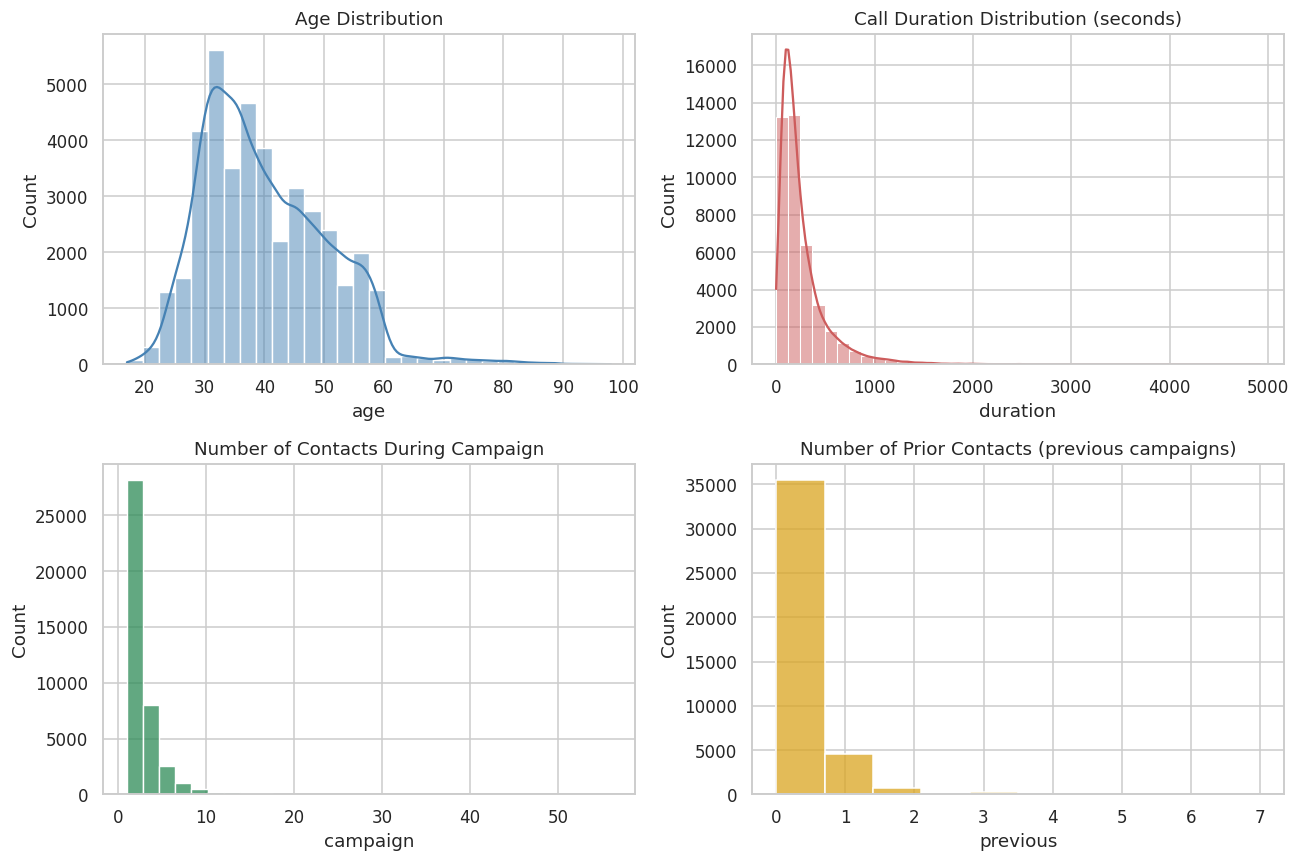

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["age"], bins=30, kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Age Distribution")
sns.histplot(df["duration"], bins=40, kde=True, ax=axes[0,1], color="indianred")
axes[0,1].set_title("Call Duration Distribution (seconds)")
sns.histplot(df["campaign"], bins=30, kde=False, ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Number of Contacts During Campaign")
sns.histplot(df["previous"], bins=10, kde=False, ax=axes[1,1], color="goldenrod")
axes[1,1].set_title("Number of Prior Contacts (previous campaigns)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numeric_histograms.png")
plt.show()

**Observations:**
- `age` is right-skewed, concentrated between 30-50 years, typical of a working-age client base.
- `duration` (call length) is strongly right-skewed with a long tail of long calls.
- `campaign` (contacts in current campaign) is heavily right-skewed — most clients contacted 1-3 times, a few outliers contacted 20+ times, suggesting diminishing-returns targeting.
- `previous` shows most clients had zero prior contact, consistent with `pdays`=999 sentinel above.

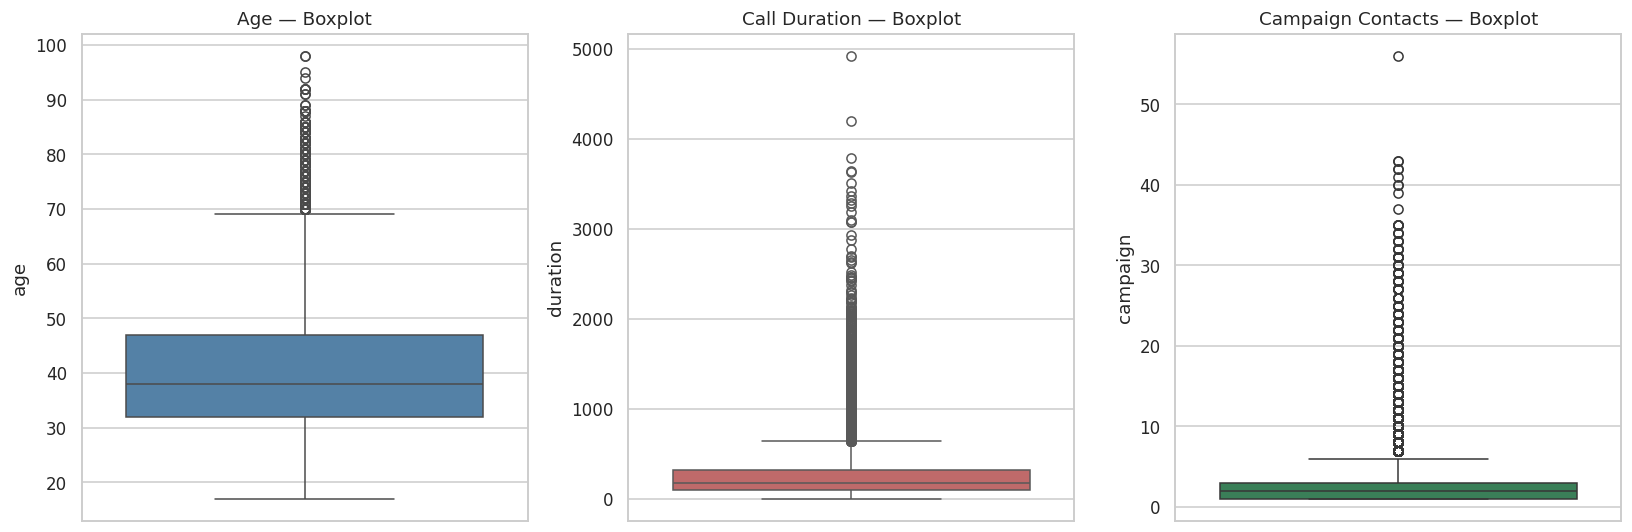

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df["age"], ax=axes[0], color="steelblue")
axes[0].set_title("Age — Boxplot")
sns.boxplot(y=df["duration"], ax=axes[1], color="indianred")
axes[1].set_title("Call Duration — Boxplot")
sns.boxplot(y=df["campaign"], ax=axes[2], color="seagreen")
axes[2].set_title("Campaign Contacts — Boxplot")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_boxplots_outliers.png")
plt.show()

In [11]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    pct = ((series < lo) | (series > hi)).mean() * 100
    return round(pct, 2), round(lo, 1), round(hi, 1)

for col in ["age", "duration", "campaign"]:
    pct, lo, hi = iqr_outlier_pct(df[col])
    print(f"{col}: {pct}% outliers outside IQR bounds [{lo}, {hi}]")

age: 1.14% outliers outside IQR bounds [9.5, 69.5]
duration: 7.2% outliers outside IQR bounds [-223.5, 644.5]
campaign: 5.84% outliers outside IQR bounds [-2.0, 6.0]


**Observation:** `campaign` and `duration` have a notable share of IQR-defined outliers (extreme
high-contact or long-call clients). These are retained (not removed) since they are legitimate business
events, but should be capped/transformed (e.g., log-transform) before modeling.

### Categorical feature distributions

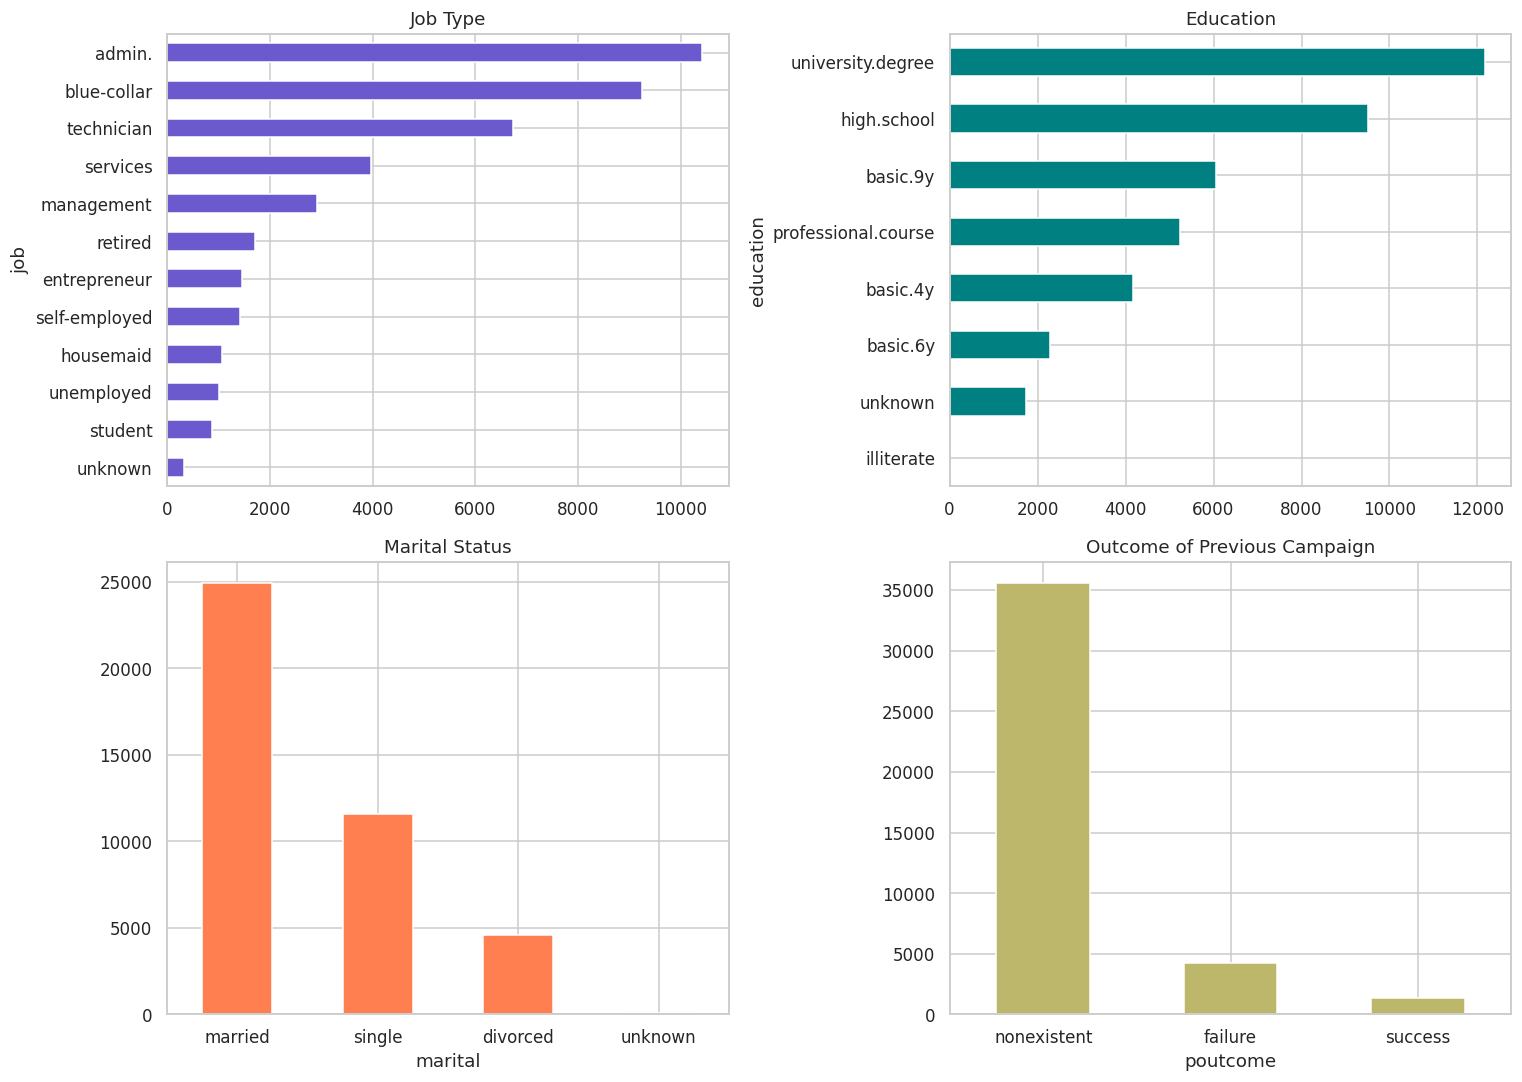

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df["job"].value_counts().plot(kind="barh", ax=axes[0,0], color="slateblue")
axes[0,0].set_title("Job Type"); axes[0,0].invert_yaxis()
df["education"].value_counts().plot(kind="barh", ax=axes[0,1], color="teal")
axes[0,1].set_title("Education"); axes[0,1].invert_yaxis()
df["marital"].value_counts().plot(kind="bar", ax=axes[1,0], color="coral")
axes[1,0].set_title("Marital Status"); axes[1,0].tick_params(axis="x", rotation=0)
df["poutcome"].value_counts().plot(kind="bar", ax=axes[1,1], color="darkkhaki")
axes[1,1].set_title("Outcome of Previous Campaign"); axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_categorical_distributions.png")
plt.show()

## 4. Bivariate Analysis — Drivers of Subscription

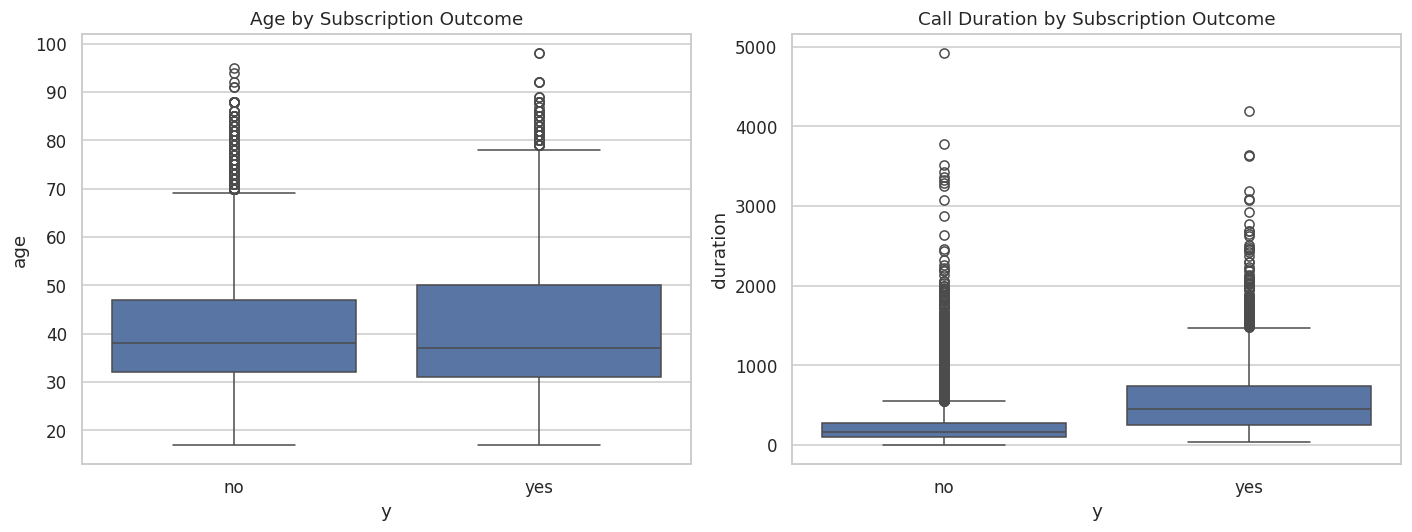

In [13]:
df["y_flag"] = (df["y"] == "yes").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="y", y="age", order=["no", "yes"], ax=axes[0])
axes[0].set_title("Age by Subscription Outcome")
sns.boxplot(data=df, x="y", y="duration", order=["no", "yes"], ax=axes[1])
axes[1].set_title("Call Duration by Subscription Outcome")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_numeric_vs_target.png")
plt.show()

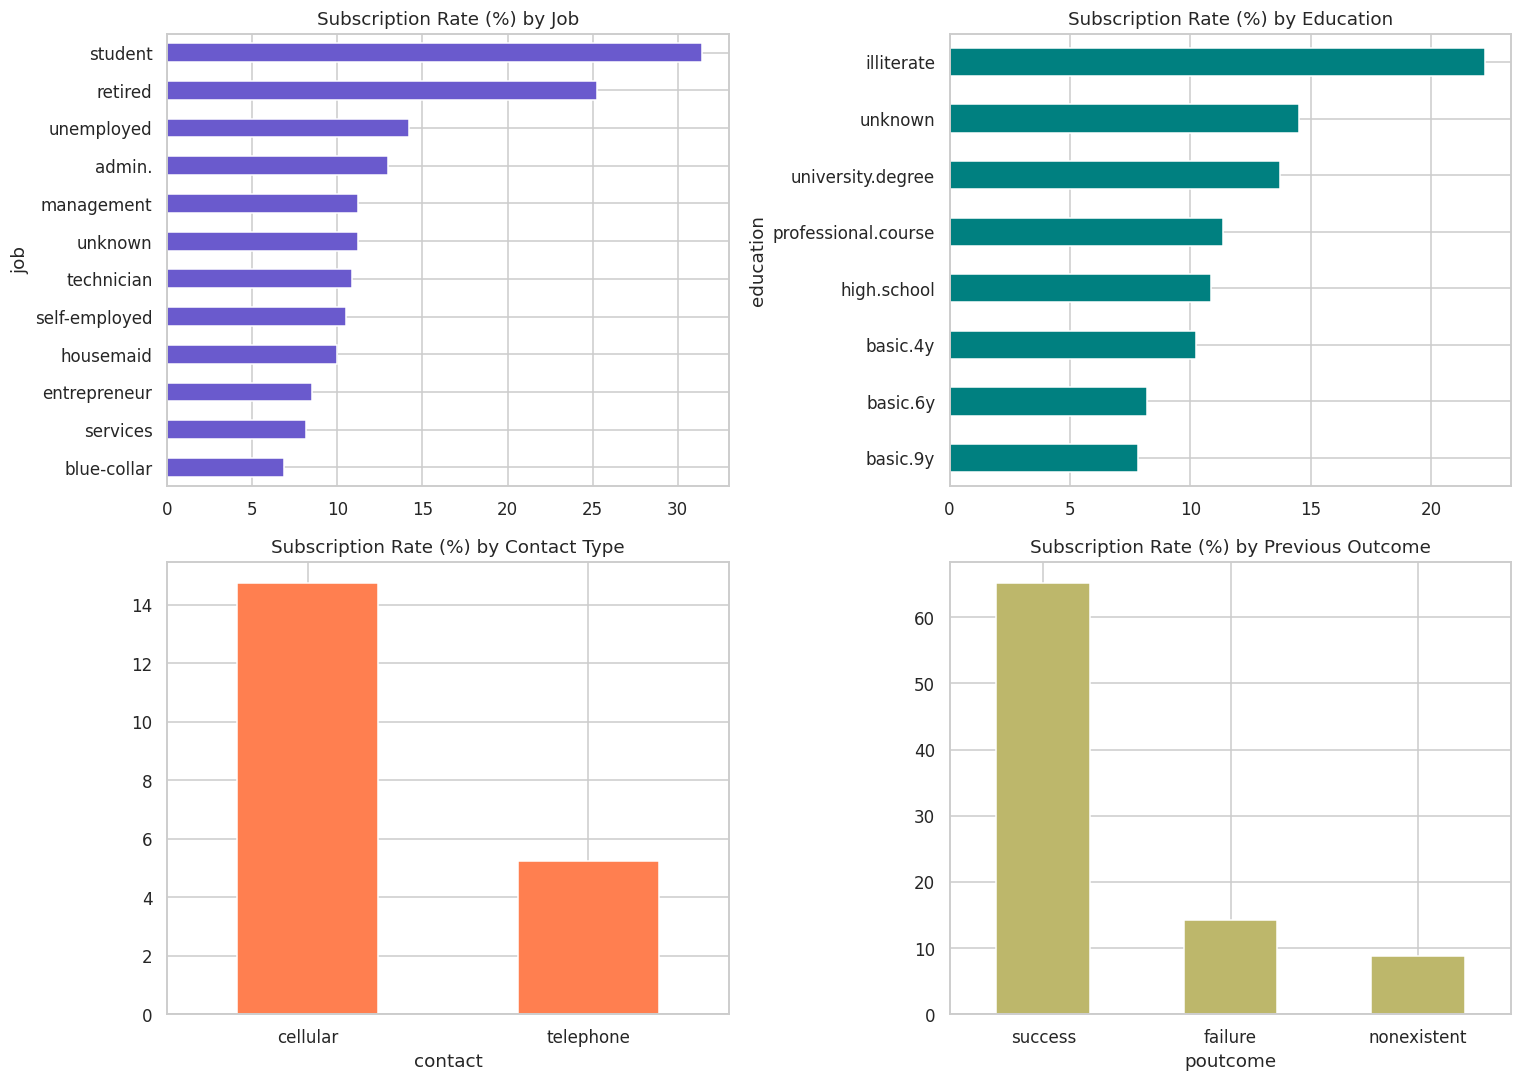

Rate by job:
 job
student          31.43
retired          25.26
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.90
Name: y_flag, dtype: float64

Rate by education:
 education
illiterate             22.22
unknown                14.51
university.degree      13.72
professional.course    11.35
high.school            10.84
basic.4y               10.25
basic.6y                8.21
basic.9y                7.82
Name: y_flag, dtype: float64

Rate by contact:
 contact
cellular     14.74
telephone     5.23
Name: y_flag, dtype: float64

Rate by poutcome:
 poutcome
success        65.11
failure        14.23
nonexistent     8.83
Name: y_flag, dtype: float64

Rate by month:
 month
mar    50.55
dec    48.90
sep    44.91
oct    43.93
apr    20.49
aug    10.61
jun    10.51
nov    10.15
jul     9.04
may     6.44
Name: y_flag, dty

In [14]:
rate_by_job = df.groupby("job")["y_flag"].mean().sort_values(ascending=False) * 100
rate_by_edu = df.groupby("education")["y_flag"].mean().sort_values(ascending=False) * 100
rate_by_contact = df.groupby("contact")["y_flag"].mean().sort_values(ascending=False) * 100
rate_by_poutcome = df.groupby("poutcome")["y_flag"].mean().sort_values(ascending=False) * 100
rate_by_month = df.groupby("month")["y_flag"].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
rate_by_job.plot(kind="barh", ax=axes[0,0], color="slateblue"); axes[0,0].set_title("Subscription Rate (%) by Job"); axes[0,0].invert_yaxis()
rate_by_edu.plot(kind="barh", ax=axes[0,1], color="teal"); axes[0,1].set_title("Subscription Rate (%) by Education"); axes[0,1].invert_yaxis()
rate_by_contact.plot(kind="bar", ax=axes[1,0], color="coral"); axes[1,0].set_title("Subscription Rate (%) by Contact Type"); axes[1,0].tick_params(axis="x", rotation=0)
rate_by_poutcome.plot(kind="bar", ax=axes[1,1], color="darkkhaki"); axes[1,1].set_title("Subscription Rate (%) by Previous Outcome"); axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_subscription_rate_by_category.png")
plt.show()

print("Rate by job:\n", rate_by_job.round(2))
print("\nRate by education:\n", rate_by_edu.round(2))
print("\nRate by contact:\n", rate_by_contact.round(2))
print("\nRate by poutcome:\n", rate_by_poutcome.round(2))
print("\nRate by month:\n", rate_by_month.round(2))

**Observations:**
- Students and retirees show the **highest** subscription rates despite being smaller segments — likely more receptive to savings products and less time-constrained.
- Clients whose **previous campaign outcome was "success"** are dramatically more likely to subscribe again — strongest behavioural signal in the dataset.
- **Cellular contact** outperforms **telephone (landline)** contact substantially.
- Subscription rate varies strongly by month, pointing to seasonality in campaign effectiveness (e.g., March/September/October/December outperform mid-year months).

## 5. Correlation Analysis

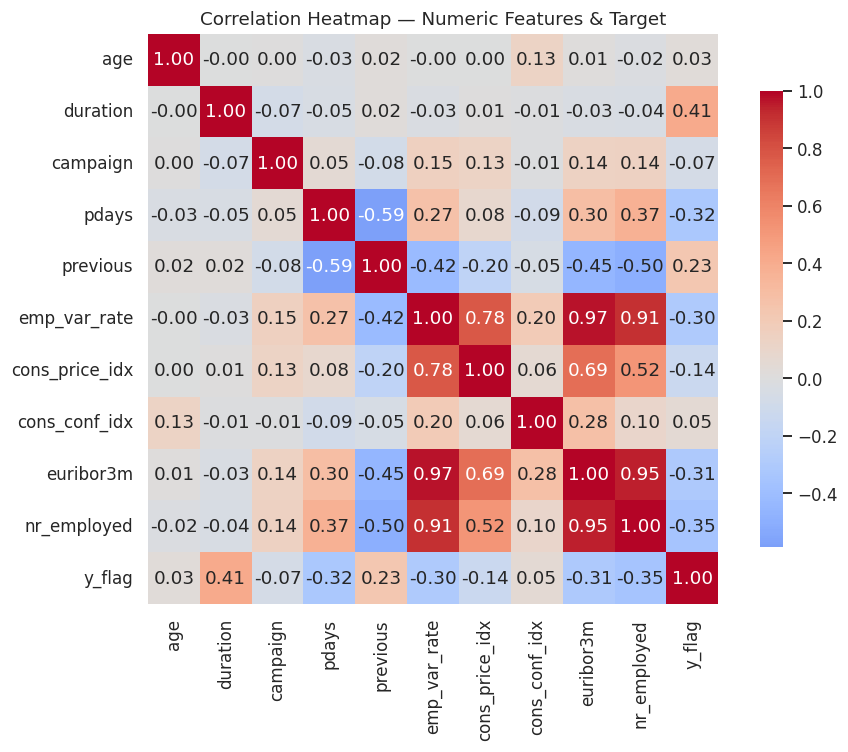

y_flag            1.000000
duration          0.405297
previous          0.230202
cons_conf_idx     0.054802
age               0.030381
campaign         -0.066361
cons_price_idx   -0.136134
emp_var_rate     -0.298289
euribor3m        -0.307740
pdays            -0.324948
nr_employed      -0.354669
Name: y_flag, dtype: float64

In [15]:
corr = df[num_cols + ["y_flag"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink":0.8})
ax.set_title("Correlation Heatmap — Numeric Features & Target")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_correlation_heatmap.png")
plt.show()
corr["y_flag"].sort_values(ascending=False)

**Observations:**
- The five macro-economic indicators (`emp_var_rate`, `cons_price_idx`, `euribor3m`, `nr_employed`,
  partially `cons_conf_idx`) are **highly inter-correlated** (multicollinearity) — only a subset should be
  used together in a linear model, or dimensionality reduction (PCA) / regularization applied.
- `duration` has the strongest positive correlation with the target, but in practice it is only known
  *after* a call ends, so it should be **excluded from realistic predictive models** (data leakage) and
  used only for descriptive/EDA purposes.
- Macro indicators are **negatively** correlated with subscription — campaigns succeed more when the
  economy is in a weaker state (clients seek safer, guaranteed-return instruments like term deposits).

## 6. Hypothesis Testing

### 6.1 Independent-samples t-test: Does mean call `duration` differ between subscribers and non-subscribers?
- H0: mean duration (yes) = mean duration (no)
- H1: mean duration (yes) ≠ mean duration (no)

In [16]:
dur_yes = df.loc[df.y == "yes", "duration"]
dur_no = df.loc[df.y == "no", "duration"]
t_stat, p_val = stats.ttest_ind(dur_yes, dur_no, equal_var=False)
print(f"Mean duration (yes): {dur_yes.mean():.1f}s | Mean duration (no): {dur_no.mean():.1f}s")
print(f"Welch t-test: t={t_stat:.2f}, p={p_val:.2e}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> Not significant")

Mean duration (yes): 553.3s | Mean duration (no): 220.9s
Welch t-test: t=55.50, p=0.00e+00
=> Statistically significant difference


### 6.2 Independent-samples t-test: Does mean `age` differ between subscribers and non-subscribers?

In [17]:
age_yes = df.loc[df.y == "yes", "age"]
age_no = df.loc[df.y == "no", "age"]
t2, p2 = stats.ttest_ind(age_yes, age_no, equal_var=False)
print(f"Mean age (yes): {age_yes.mean():.1f} | Mean age (no): {age_no.mean():.1f}")
print(f"Welch t-test: t={t2:.2f}, p={p2:.2e}")
print("=> Statistically significant difference" if p2 < 0.05 else "=> Not significant")

Mean age (yes): 40.9 | Mean age (no): 39.9
Welch t-test: t=4.78, p=1.84e-06
=> Statistically significant difference


### 6.3 Chi-square tests of independence: categorical predictors vs subscription outcome

In [18]:
chi_results = []
for col in ["job", "marital", "education", "contact", "poutcome", "housing", "loan", "default"]:
    ct = pd.crosstab(df[col], df["y"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi_results.append({"feature": col, "chi2": round(chi2,2), "dof": dof, "p_value": p,
                         "significant_at_0.05": p < 0.05})
chi_df = pd.DataFrame(chi_results).sort_values("chi2", ascending=False)
chi_df

,feature,chi2,dof,p_value,significant_at_0.05
4,poutcome,4230.14,2,0.000000e+00,True
0,job,961.74,11,3.268412e-199,True
3,contact,862.08,1,1.718741e-189,True
7,default,406.56,2,5.217541e-89,True
2,education,192.85,7,3.746768e-38,True
1,marital,122.96,3,1.778423e-26,True
5,housing,5.74,2,5.663793e-02,False
6,loan,1.10,2,5.771532e-01,False


**Observation:** All tested categorical variables show a statistically significant association with
subscription outcome (p < 0.05), with `poutcome`, `contact` and `job` showing the strongest chi-square
statistics — confirming they are meaningful segmentation variables for campaign targeting.

### 6.4 One-way ANOVA: Does mean `age` differ across `education` levels?

In [19]:
groups = [g["age"].values for _, g in df.groupby("education")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA F={f_stat:.2f}, p={p_anova:.2e}")
print("=> Significant difference in mean age across education levels" if p_anova < 0.05 else "=> Not significant")

ANOVA F=457.37, p=0.00e+00
=> Significant difference in mean age across education levels


## 7. Key Insights Summary

1. **Severe class imbalance** (~11% positive class) — must be handled explicitly in any future predictive model.
2. **Call duration** is the single strongest correlate of success but is not usable for real-time prediction (only known post-call) — a classic leakage trap for beginners to avoid.
3. **Prior campaign success (`poutcome`=success)** is the strongest actionable behavioural signal — clients who converted before are far more likely to convert again. This supports building a "warm lead" retargeting list.
4. **Cellular contact channel** significantly outperforms landline telephone — supports shifting contact strategy fully to mobile.
5. **Job segment and life-stage matter**: students and retirees convert at much higher rates than blue-collar/entrepreneur segments, despite being smaller populations — suggests a segment-specific campaign script/offer could lift ROI.
5. **Macro-economic climate matters**: campaigns are more successful during weaker economic conditions (higher unemployment variation, lower employment index) — deposits become relatively more attractive versus other investments.
6. **Seasonality**: subscription rate is highly month-dependent, useful for campaign calendar planning.
7. All categorical predictors tested are statistically significantly associated with the outcome (chi-square), and both `age` and `duration` differ significantly by outcome (t-tests) — validating that a supervised classification model is a reasonable next step.

## 8. Assumptions & Limitations
- `unknown` categorical values were retained as their own category rather than imputed, since their prevalence may itself carry signal (non-response bias) and the dataset is large enough to absorb this.
- `pdays`=999 was interpreted as "not previously contacted" (per dataset documentation) and converted into a flag rather than treated as a genuine numeric value, to avoid distorting `pdays` statistics.
- Outliers in `campaign`/`duration` were not removed, as they reflect real telemarketing behaviour, not data errors; they are flagged for transformation in a modeling phase.
- The dataset covers a specific bank/time period (Portugal, 2008-2010 economic-crisis era); findings on macro-sensitivity may not generalize directly to other markets or eras without re-validation.
- Two-sided tests were used throughout with alpha = 0.05.